# LightGlue Demo
In this notebook we match two pairs of images using LightGlue with early stopping and point pruning.

In [1]:
# If we are on colab: this clones the repo and installs the dependencies
from pathlib import Path

if Path.cwd().name != "LightGlue":
    !git clone --quiet https://github.com/cvg/LightGlue/
    %cd LightGlue
    !pip install --progress-bar off --quiet -e .

from lightglue import LightGlue, SuperPoint, DISK, SIFT, DoGHardNet, ALIKED
from lightglue.utils import load_image, rbd
from lightglue import viz2d
import torch

torch.set_grad_enabled(False)
images = Path("assets")

## Load extractor and matcher module
In this example we use SuperPoint features combined with LightGlue.

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)

## Easy example
The top image shows the matches, while the bottom image shows the point pruning across layers. In this case, LightGlue prunes a few points with occlusions, but is able to stop the context aggregation after 4/9 layers.

R: [[-0.67853112  0.73457079  0.00113025]
 [ 0.73378605  0.6777335   0.04727928]
 [ 0.03396397  0.03290983 -0.99888107]], t: [ 0.54256983 -0.83915717 -0.03785797]


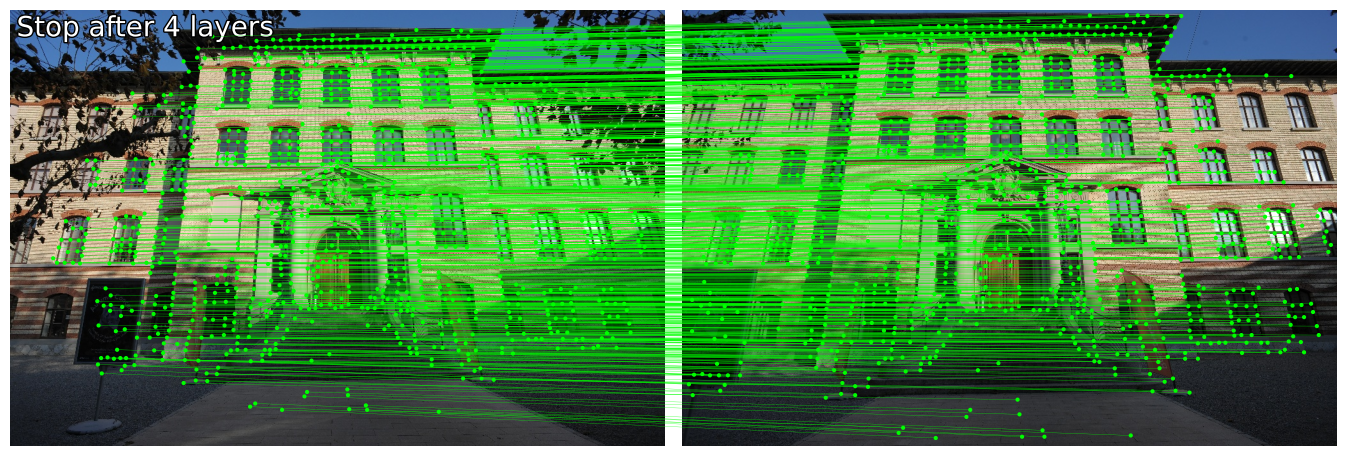

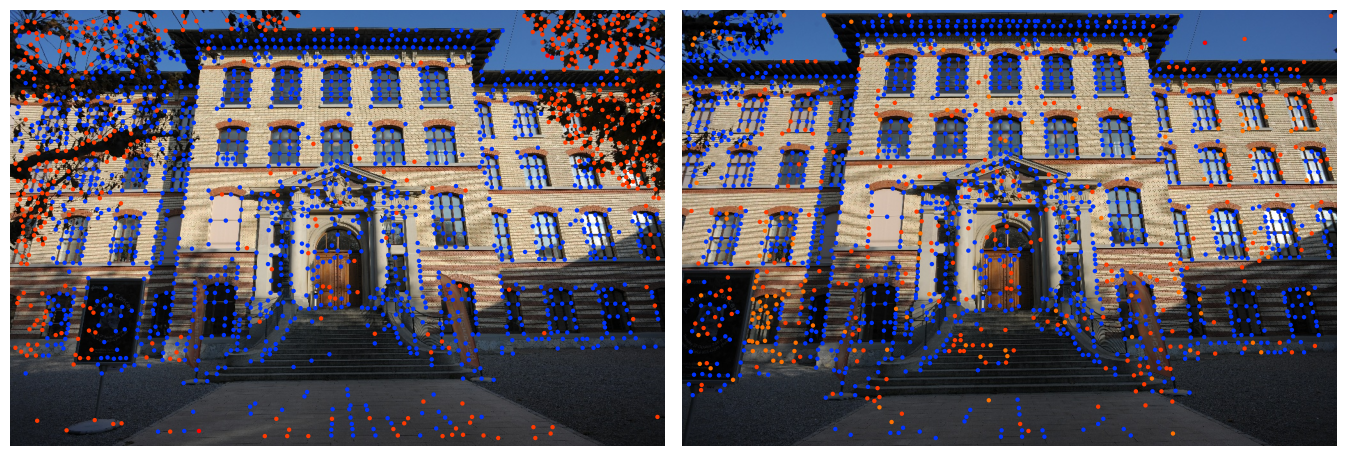

In [5]:
image0 = load_image(images / "DSC_0411.JPG")
image1 = load_image(images / "DSC_0410.JPG")

feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

# do pose estimation with the matches
import cv2
E, mask = cv2.findEssentialMat(kpts0.cpu().numpy(), kpts1.cpu().numpy(), method=cv2.RANSAC, prob=0.999, threshold=1.0)
_, R, t, mask = cv2.recoverPose(E, kpts0.cpu().numpy(), kpts1.cpu().numpy(), mask=mask)
print(f"R: {R.squeeze()}, t: {t.squeeze()}")

## Difficult example
For pairs with significant viewpoint- and illumination changes, LightGlue can exclude a lot of points early in the matching process (red points), which significantly reduces the inference time.

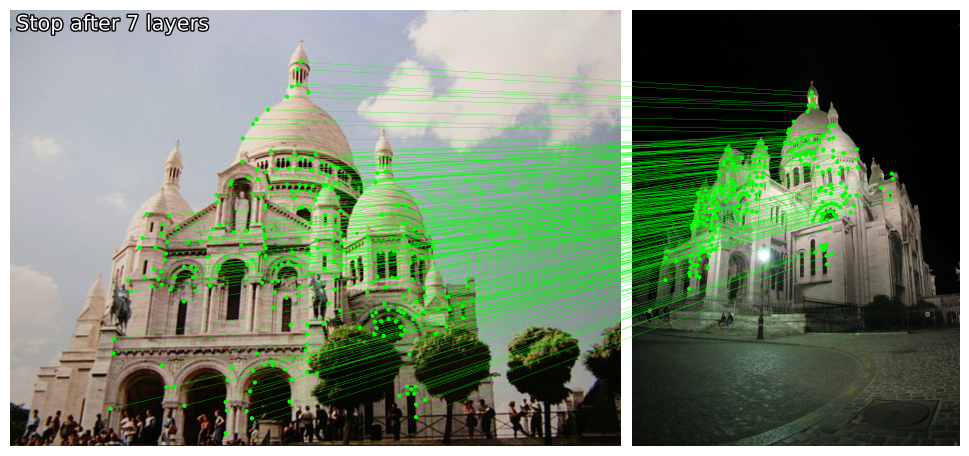

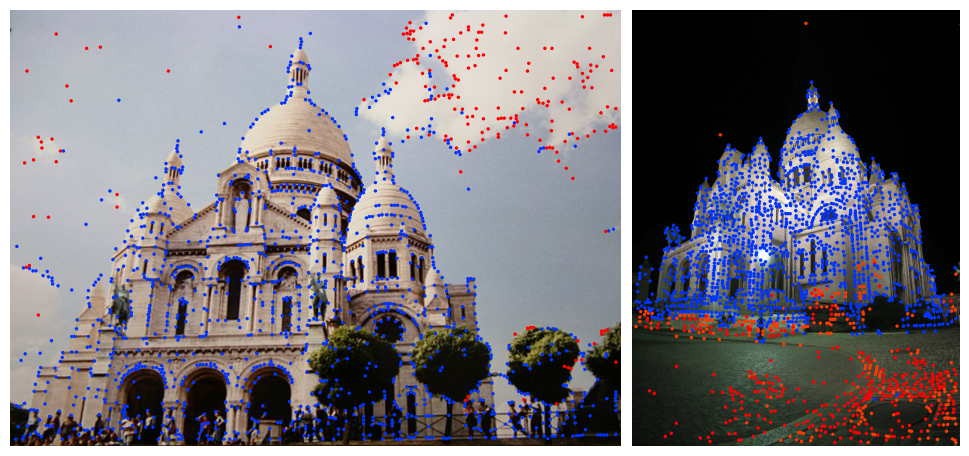

In [26]:
image0 = load_image(images / "sacre_coeur1.jpg")
image1 = load_image(images / "sacre_coeur2.jpg")

feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers')

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=6)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from lightglue.utils import numpy_image_to_torch
import os
from tqdm import tqdm

path = '/media/liming/Base/datasets/realestate/test/00a5a2af678f37d5/data.npz'
re_10k_exp = np.load(path)
print(re_10k_exp.files)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SIFT(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="sift").eval().to(device)

img0 = re_10k_exp[re_10k_exp.files[0]]

for i in tqdm(range(1, len(re_10k_exp.files))):
# for i in range(1, 20):
    img_curr = re_10k_exp[re_10k_exp.files[i]]
    image1 = numpy_image_to_torch(img_curr)
    feats1 = extractor.extract(image1.to(device))
    image0 = numpy_image_to_torch(img0)
    feats0 = extractor.extract(image0.to(device))
    
    matches01 = matcher({"image0": feats0, "image1": feats1})
    feats0, feats1, matches01 = [
        rbd(x) for x in [feats0, feats1, matches01]
    ]  # remove batch dimension
    
    kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

    axes = viz2d.plot_images([image0, image1])
    viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
    viz2d.add_text(0, f'Stop after {matches01["stop"]} layers')

    # Create the output directory if it does not exist
    os.makedirs('output_sift', exist_ok=True)

    # Save the current image without displaying it
    plt.savefig(f'output_sift/{i}.png')
    plt.close()




['188188000.jpg', '188221367.jpg', '188254733.jpg', '188288100.jpg', '188321467.jpg', '188354833.jpg', '188388200.jpg', '188421567.jpg', '188454933.jpg', '188488300.jpg', '188521667.jpg', '188555033.jpg', '188588400.jpg', '188621767.jpg', '188655133.jpg', '188688500.jpg', '188721867.jpg', '188788600.jpg', '188821967.jpg', '188855333.jpg', '188888700.jpg', '188922067.jpg', '188955433.jpg', '188988800.jpg', '189022167.jpg', '189055533.jpg', '189088900.jpg', '189122267.jpg', '189155633.jpg', '189189000.jpg', '189222367.jpg', '189255733.jpg', '189289100.jpg', '189322467.jpg', '189389200.jpg', '189422567.jpg', '189455933.jpg', '189489300.jpg', '189522667.jpg', '189556033.jpg', '189589400.jpg', '189622767.jpg', '189656133.jpg', '189689500.jpg', '189722867.jpg', '189756233.jpg', '189789600.jpg', '189822967.jpg', '189856333.jpg', '189889700.jpg', '189923067.jpg', '189989800.jpg', '190023167.jpg', '190056533.jpg', '190089900.jpg', '190123267.jpg', '190156633.jpg', '190190000.jpg', '190223367.jp

Downloading: "https://github.com/cvg/LightGlue/releases/download/v0.1_arxiv/sift_lightglue.pth" to /home/liming/.cache/torch/hub/checkpoints/sift_lightglue_v0-1_arxiv.pth
100.0%
100%|██████████| 131/131 [01:53<00:00,  1.15it/s]


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from lightglue.utils import numpy_image_to_torch
import os
from tqdm import tqdm

path = '/media/liming/Base/datasets/realestate/test/00a5a2af678f37d5/data.npz'
txt_path = '/media/liming/Base/datasets/RealEstate10K/test/00a5a2af678f37d5.txt'
# path = '/media/liming/Base/datasets/realestate/test/0a45b99f42fb0ecb/data.npz'
re_10k_exp = np.load(path)
re_10k_txt = np.loadtxt(txt_path, dtype=str)
print(re_10k_exp.files)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # 'mps', 'cpu'

extractor = SuperPoint(max_num_keypoints=2048).eval().to(device)  # load the extractor
matcher = LightGlue(features="superpoint").eval().to(device)

img0 = re_10k_exp[re_10k_exp.files[0]]
image0 = numpy_image_to_torch(img0)
feats0 = extractor.extract(image0.to(device))
for i in tqdm(range(1, len(re_10k_exp.files))):
# for i in range(1, 20):
    img_curr = re_10k_exp[re_10k_exp.files[i]]
    image1 = numpy_image_to_torch(img_curr)
    feats1 = extractor.extract(image1.to(device))
    
    matches01 = matcher({"image0": feats0, "image1": feats1})
    feats0_nobatch, feats1, matches01 = [
        rbd(x) for x in [feats0, feats1, matches01]
    ]  # remove batch dimension
    
    kpts0, kpts1, matches = feats0_nobatch["keypoints"], feats1["keypoints"], matches01["matches"]
    m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

    axes = viz2d.plot_images([image0, image1])
    viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
    viz2d.add_text(0, f'Stop after {matches01["stop"]} layers')

    # Create the output directory if it does not exist
    os.makedirs('output', exist_ok=True)

    # Save the current image without displaying it
    plt.savefig(f'output/{i}.png')
    plt.close()




['188188000.jpg', '188221367.jpg', '188254733.jpg', '188288100.jpg', '188321467.jpg', '188354833.jpg', '188388200.jpg', '188421567.jpg', '188454933.jpg', '188488300.jpg', '188521667.jpg', '188555033.jpg', '188588400.jpg', '188621767.jpg', '188655133.jpg', '188688500.jpg', '188721867.jpg', '188788600.jpg', '188821967.jpg', '188855333.jpg', '188888700.jpg', '188922067.jpg', '188955433.jpg', '188988800.jpg', '189022167.jpg', '189055533.jpg', '189088900.jpg', '189122267.jpg', '189155633.jpg', '189189000.jpg', '189222367.jpg', '189255733.jpg', '189289100.jpg', '189322467.jpg', '189389200.jpg', '189422567.jpg', '189455933.jpg', '189489300.jpg', '189522667.jpg', '189556033.jpg', '189589400.jpg', '189622767.jpg', '189656133.jpg', '189689500.jpg', '189722867.jpg', '189756233.jpg', '189789600.jpg', '189822967.jpg', '189856333.jpg', '189889700.jpg', '189923067.jpg', '189989800.jpg', '190023167.jpg', '190056533.jpg', '190089900.jpg', '190123267.jpg', '190156633.jpg', '190190000.jpg', '190223367.jp

KeyboardInterrupt: 

### Triangualtion


In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_triangulated_points(points_3d, reprojection_errors=None, save_path=None):
    """
    Visualize 3D points from triangulation.
    
    Args:
    - points_3d: Numpy array of 3D points (Nx3)
    - reprojection_errors: Optional array of reprojection errors to color-code points
    - save_path: Optional path to save the figure
    """
    # Create a 3D plot
    fig = plt.figure(figsize=(12, 5))
    
    # 3D scatter plot
    ax1 = fig.add_subplot(121, projection='3d')
    
    if reprojection_errors is not None:
        # Color points based on reprojection error
        scatter = ax1.scatter(points_3d[:, 0], 
                               points_3d[:, 1], 
                               points_3d[:, 2], 
                               c=reprojection_errors, 
                               cmap='viridis')
        plt.colorbar(scatter, ax=ax1, label='Reprojection Error')
        ax1.set_title('Triangulated Points (Colored by Reprojection Error)')
    else:
        ax1.scatter(points_3d[:, 0], points_3d[:, 1], points_3d[:, 2])
        ax1.set_title('Triangulated Points')
    
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')

    # Depth distribution histogram
    ax2 = fig.add_subplot(122)
    depths = np.linalg.norm(points_3d, axis=1)
    ax2.hist(depths, bins=50, edgecolor='black')
    ax2.set_title('Depth Distribution')
    ax2.set_xlabel('Depth')
    ax2.set_ylabel('Frequency')

    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path)
    else:
        plt.show()
        
def triangulate_matches(kpts0, kpts1, K1, K2, R, t):
    """
    Triangulate matched points to obtain 3D points.
    
    Args:
    - kpts0, kpts1: Matched keypoints from two images
    - K1, K2: Camera intrinsic matrices
    - R, t: Relative rotation and translation between cameras
    
    Returns:
    - 3D points from triangulation
    - Reprojection errors
    """
    # Create projection matrices
    # Camera 1 (reference camera)
    P1 = K1 @ np.eye(4)[:3, :]
    
    # Camera 2 (transformed camera)
    P2 = K2 @ np.hstack((R, t.reshape(3,1)))
    
    # Triangulate points
    points_4d = cv2.triangulatePoints(P1, P2, 
                                      kpts0.T, 
                                      kpts1.T)
    
    # Convert from homogeneous to 3D points
    points_3d = points_4d[:3, :] / points_4d[3, :]
    
    # Compute reprojection errors
    reprojection_errors = []
    for i in range(points_3d.shape[1]):
        # Reproject 3D point back to both images
        pt1 = K1 @ points_3d[:, i]
        pt1 /= pt1[2]
        
        pt2 = K2 @ (R @ points_3d[:, i] + t)
        pt2 /= pt2[2]
        
        # Calculate reprojection error
        err1 = np.linalg.norm(pt1[:2] - kpts0[i])
        err2 = np.linalg.norm(pt2[:2] - kpts1[i])
        reprojection_errors.append((err1 + err2) / 2)
    
    return points_3d.T, np.array(reprojection_errors)

In [ ]:
image0 = load_image(images / "DSC_0411.JPG")
image1 = load_image(images / "DSC_0410.JPG")

feats0 = extractor.extract(image0.to(device))
feats1 = extractor.extract(image1.to(device))
matches01 = matcher({"image0": feats0, "image1": feats1})
feats0, feats1, matches01 = [
    rbd(x) for x in [feats0, feats1, matches01]
]  # remove batch dimension

kpts0, kpts1, matches = feats0["keypoints"], feats1["keypoints"], matches01["matches"]
m_kpts0, m_kpts1 = kpts0[matches[..., 0]], kpts1[matches[..., 1]]

axes = viz2d.plot_images([image0, image1])
viz2d.plot_matches(m_kpts0, m_kpts1, color="lime", lw=0.2)
viz2d.add_text(0, f'Stop after {matches01["stop"]} layers', fs=20)

kpc0, kpc1 = viz2d.cm_prune(matches01["prune0"]), viz2d.cm_prune(matches01["prune1"])
viz2d.plot_images([image0, image1])
viz2d.plot_keypoints([kpts0, kpts1], colors=[kpc0, kpc1], ps=10)

points_3d = triangulate_matches(kpts0.cpu().numpy(), kpts1.cpu().numpy(), K1, K2, R, t)
visualize_triangulated_points(points_3d, save_path='output/triangulated_points.png')